# Cross-Sectional Estimation with Vol-Scaled Lambda

Runs Stage-1 (rolling LASSO) + Stage-2 (NLS for kappa) on all estimation stocks
using a **per-stock volatility-scaled penalty**:

$$\lambda_i = \lambda^* \times \frac{\sigma_i}{\bar\sigma}$$

where $\sigma_i$ is the full-sample daily return std of stock $i$ and
$\bar\sigma = 0.0175$ is the cross-sectional median.

## Checkpointing

Each stock is saved as an individual pickle file inside `CACHE_DIR` immediately
after estimation. If the run is interrupted, re-executing this notebook skips
stocks that already have a cache file. The assembly cell then merges everything
into `betas.h5` + `summary.csv`.


In [1]:
import sys, os, warnings, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from joblib import Parallel, delayed

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('.').resolve()
REPO_ROOT    = NOTEBOOK_DIR.parent.parent          # Lasso_paper/
SCRIPTS_DIR  = REPO_ROOT / 'Empirical' / 'scripts'
DATA_DIR     = REPO_ROOT / 'Data'
OUT_DIR      = REPO_ROOT / 'Results' / 'Estimation' / 'Cross_Sectional_volscaled'
CACHE_DIR    = OUT_DIR / '_cache'                  # per-stock pickle files

OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SCRIPTS_DIR))
from grid_search import estimate_single_config_fast
from stage2 import compute_alm_returns

# ── Hyperparameters ───────────────────────────────────────────────────────────
HP_FILE = DATA_DIR / 'clean_data' / 'best_hyperparameters_holdout.txt'
hp = {}
with open(HP_FILE) as f:
    for line in f:
        if ':' in line:
            k, v = line.strip().split(': ', 1)
            try: hp[k] = float(v)
            except ValueError: hp[k] = v

BEST_LAMBDA = hp['lambda']
BEST_WINDOW = int(hp['window_size'])
N_LAGS      = int(hp['n_lags'])
TARGET_VOL  = 0.0175   # cross-sectional median daily return std
N_JOBS      = -1       # use all cores
BATCH_SIZE  = 50       # stocks per checkpoint flush

print(f'lambda*     = {BEST_LAMBDA:.4e}')
print(f'window*     = {BEST_WINDOW}')
print(f'n_lags      = {N_LAGS}')
print(f'TARGET_VOL  = {TARGET_VOL}')
print(f'Output dir  : {OUT_DIR}')
print(f'Cache dir   : {CACHE_DIR}')


lambda*     = 3.5059e-03
window*     = 231
n_lags      = 1
TARGET_VOL  = 0.0175
Output dir  : /Users/tommasodifrancesco/Desktop/Lasso_paper/Results/Estimation/Cross_Sectional_volscaled
Cache dir   : /Users/tommasodifrancesco/Desktop/Lasso_paper/Results/Estimation/Cross_Sectional_volscaled/_cache


In [2]:
X_all = pd.read_csv(DATA_DIR / 'clean_data' / 'final_macro_topic_features.csv',
                    index_col=0, parse_dates=True)
R_all = pd.read_csv(DATA_DIR / 'data_raw' / 'cross_sectional_returns.csv',
                    index_col=0, parse_dates=True)

common_idx = X_all.index.intersection(R_all.index)
X_all = X_all.loc[common_idx]
R_all = R_all.loc[common_idx]

# Standardise column names to match cross_sectional_estimation.py convention
X_all.columns = [str(c).replace(' ', '_') for c in X_all.columns]
FEATURE_NAMES = list(X_all.columns)

print(f'Features : {X_all.shape}')
print(f'Returns  : {R_all.shape}')
print(f'Common   : {len(common_idx)} days  [{common_idx[0].date()} to {common_idx[-1].date()}]')


Features : (1879, 190)
Returns  : (1879, 1620)
Common   : 1879 days  [2010-01-19 to 2017-06-30]


In [3]:
# Load the estimation stock list produced by find_hyperparameters_holdout
estim_csv = NOTEBOOK_DIR / 'estim_stocks.csv'
estim_tickers = pd.read_csv(estim_csv)['stock'].astype(str).str.split('.').str[0].tolist()

# Map to R_all column names (columns may have trailing .0)
r_col_map = {str(c).split('.')[0]: c for c in R_all.columns}
STOCKS = [s for s in estim_tickers if s in r_col_map]

# Pre-compute per-stock return volatility and effective lambda
stock_vols  = {s: float(R_all[r_col_map[s]].dropna().std()) for s in STOCKS}
eff_lambdas = {s: BEST_LAMBDA * (stock_vols[s] / TARGET_VOL) for s in STOCKS}

lam_vals = list(eff_lambdas.values())
print(f'Estimation stocks : {len(STOCKS)}')
print(f'Effective lambda  : min={min(lam_vals):.4e}  '
      f'median={np.median(lam_vals):.4e}  max={max(lam_vals):.4e}')


Estimation stocks : 1296
Effective lambda  : min=8.7591e-04  median=3.5190e-03  max=3.3235e-02


In [4]:
import re

_LAG1_RE = re.compile(r'^Lasso_(.+)_lag_1$')


def process_stock(st):
    col     = r_col_map[st]
    r       = R_all[col].dropna()
    eff_lam = eff_lambdas[st]

    if len(r) < BEST_WINDOW + N_LAGS + 100:
        return {'stock': st, 'failed': True, 'reason': 'too short'}

    X = X_all.loc[r.index]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        try:
            res = estimate_single_config_fast(
                X=X, y=r, window_size=BEST_WINDOW,
                n_lags=N_LAGS, lambda_val=eff_lam, return_details=True
            )
        except Exception as e:
            return {'stock': st, 'failed': True, 'reason': str(e)}

    details = res.get('details')
    if details is None or details.empty:
        return {'stock': st, 'failed': True, 'reason': 'empty details'}

    summary = dict(res.get('summary') or {})
    summary['stock']      = st
    summary['eff_lambda'] = eff_lam
    summary['stock_vol']  = stock_vols[st]

    # Extract per-window betas (lag-1 columns only)
    topic_cols = {}
    for c in details.columns:
        m = _LAG1_RE.match(str(c))
        if m:
            topic_cols[m.group(1)] = c
    topics_found = sorted(topic_cols.keys())

    valid    = details['date'].notna() if 'date' in details.columns else pd.Series(True, index=details.index)
    sub      = details.loc[valid]
    date_arr = pd.to_datetime(sub['date']).to_numpy()
    beta_arr = sub[[topic_cols[t] for t in topics_found]].to_numpy(dtype=np.float32)
    r2in_arr = sub['lasso_r2_in'].to_numpy(dtype=np.float32)
    pred_arr = sub['prediction'].to_numpy(dtype=np.float32)
    targ_arr = sub['target'].to_numpy(dtype=np.float32)
    icpt_arr = sub['lasso_intercept'].to_numpy(dtype=np.float32)

    # Stage-2 OOS predictions
    kappa      = summary.get('kappa', np.nan)
    intercept2 = summary.get('intercept', np.nan)
    stg2_pred  = np.full(len(pred_arr), np.nan, dtype=np.float32)
    if np.isfinite(kappa) and np.isfinite(intercept2) and len(pred_arr) > 1:
        try:
            alm = compute_alm_returns(pred_arr, kappa, intercept2)
            stg2_pred[1:] = alm
        except Exception:
            pass

    return {
        'stock': st, 'failed': False,
        'topics': topics_found, 'dates': date_arr,
        'betas': beta_arr, 'r2_in': r2in_arr,
        'predictions': pred_arr, 'targets': targ_arr,
        'intercepts': icpt_arr, 'stg2_preds': stg2_pred,
        'summary': summary,
    }


print('process_stock() defined.')


process_stock() defined.


In [5]:
def cache_path(st):
    return CACHE_DIR / f'{st}.pkl'

def already_done(st):
    return cache_path(st).exists()

def save_cache(result):
    with open(cache_path(result['stock']), 'wb') as f:
        pickle.dump(result, f, protocol=4)


done    = [s for s in STOCKS if already_done(s)]
pending = [s for s in STOCKS if not already_done(s)]
print(f'Total   : {len(STOCKS)}')
print(f'Cached  : {len(done)}')
print(f'Pending : {len(pending)}')

batches = [pending[i:i+BATCH_SIZE] for i in range(0, len(pending), BATCH_SIZE)]
print(f'Batches : {len(batches)} x {BATCH_SIZE} stocks each')

for b_idx, batch in enumerate(batches):
    results = Parallel(n_jobs=N_JOBS, backend='loky')(
        delayed(process_stock)(st) for st in batch
    )
    n_ok = n_fail = 0
    for r in results:
        save_cache(r)
        if r['failed']: n_fail += 1
        else:           n_ok   += 1
    print(f'  Batch {b_idx+1}/{len(batches)}: {n_ok} ok, {n_fail} failed  -> cache flushed')

print('Estimation complete.')


Total   : 1296
Cached  : 0
Pending : 1296
Batches : 26 x 50 stocks each
  Batch 1/26: 50 ok, 0 failed  -> cache flushed
  Batch 2/26: 50 ok, 0 failed  -> cache flushed
  Batch 3/26: 50 ok, 0 failed  -> cache flushed
  Batch 4/26: 50 ok, 0 failed  -> cache flushed
  Batch 5/26: 50 ok, 0 failed  -> cache flushed
  Batch 6/26: 50 ok, 0 failed  -> cache flushed
  Batch 7/26: 50 ok, 0 failed  -> cache flushed
  Batch 8/26: 50 ok, 0 failed  -> cache flushed
  Batch 9/26: 50 ok, 0 failed  -> cache flushed
  Batch 10/26: 50 ok, 0 failed  -> cache flushed
  Batch 11/26: 50 ok, 0 failed  -> cache flushed
  Batch 12/26: 50 ok, 0 failed  -> cache flushed
  Batch 13/26: 50 ok, 0 failed  -> cache flushed
  Batch 14/26: 50 ok, 0 failed  -> cache flushed
  Batch 15/26: 50 ok, 0 failed  -> cache flushed
  Batch 16/26: 50 ok, 0 failed  -> cache flushed
  Batch 17/26: 50 ok, 0 failed  -> cache flushed
  Batch 18/26: 50 ok, 0 failed  -> cache flushed
  Batch 19/26: 50 ok, 0 failed  -> cache flushed
  Batc

In [6]:
# Load all cached results
all_results = []
for st in STOCKS:
    p = cache_path(st)
    if p.exists():
        with open(p, 'rb') as f:
            all_results.append(pickle.load(f))

ok_results = [r for r in all_results if not r['failed']]
print(f'Loaded  : {len(all_results)} from cache')
print(f'Usable  : {len(ok_results)}')
print(f'Failed  : {len(all_results) - len(ok_results)}')

# Build unified date index and topic list
all_date_strs = set()
topics_ref = None
for r in ok_results:
    for d in r['dates']:
        all_date_strs.add(str(pd.Timestamp(d))[:10])
    if topics_ref is None:
        topics_ref = r['topics']

date_strs = sorted(all_date_strs)
date_to_i = {d: i for i, d in enumerate(date_strs)}
n_stocks  = len(STOCKS)
n_topics  = len(topics_ref)
n_dates   = len(date_strs)
stock_to_i = {s: i for i, s in enumerate(STOCKS)}
print(f'Tensor  : ({n_stocks}, {n_topics}, {n_dates})')

# Allocate tensors
T_betas   = np.full((n_stocks, n_topics, n_dates), np.nan, dtype=np.float32)
T_r2in    = np.full((n_stocks, n_dates),           np.nan, dtype=np.float32)
T_preds   = np.full((n_stocks, n_dates),           np.nan, dtype=np.float32)
T_targets = np.full((n_stocks, n_dates),           np.nan, dtype=np.float32)
T_icpts   = np.full((n_stocks, n_dates),           np.nan, dtype=np.float32)
T_stg2    = np.full((n_stocks, n_dates),           np.nan, dtype=np.float32)
summary_rows = []

for r in ok_results:
    si = stock_to_i[r['stock']]
    for j, d in enumerate(r['dates']):
        k = date_to_i.get(str(pd.Timestamp(d))[:10])
        if k is None: continue
        T_betas[si, :, k]  = r['betas'][j]
        T_r2in[si, k]      = r['r2_in'][j]
        T_preds[si, k]     = r['predictions'][j]
        T_targets[si, k]   = r['targets'][j]
        T_icpts[si, k]     = r['intercepts'][j]
        T_stg2[si, k]      = r['stg2_preds'][j]
    summary_rows.append(r['summary'])

for r in all_results:
    if r['failed']:
        summary_rows.append({'stock': r['stock'], 'failed': True,
                             'reason': r.get('reason', '')})

summary_df = pd.DataFrame(summary_rows).set_index('stock')

# Save
h5_path = OUT_DIR / 'betas.h5'
with h5py.File(h5_path, 'w') as f:
    kw = dict(dtype='float32', compression='gzip', compression_opts=4)
    f.create_dataset('betas',               data=T_betas,   **kw)
    f.create_dataset('r2_in',               data=T_r2in,    **kw)
    f.create_dataset('predictions',         data=T_preds,   **kw)
    f.create_dataset('targets',             data=T_targets, **kw)
    f.create_dataset('lasso_intercepts',    data=T_icpts,   **kw)
    f.create_dataset('stage2_predictions',  data=T_stg2,    **kw)
    sd = h5py.string_dtype()
    f.create_dataset('stocks', data=np.array(STOCKS,     dtype=sd))
    f.create_dataset('topics', data=np.array(topics_ref, dtype=sd))
    f.create_dataset('dates',  data=np.array(date_strs,  dtype=sd))

summary_df.to_csv(OUT_DIR / 'summary.csv')
print(f'Saved betas.h5  -> {h5_path}  {T_betas.shape}  ({T_betas.nbytes/1e9:.2f} GB uncompressed)')
print(f'Saved summary.csv -> {OUT_DIR / "summary.csv"}')


Loaded  : 1296 from cache
Usable  : 1296
Failed  : 0
Tensor  : (1296, 190, 1648)
Saved betas.h5  -> /Users/tommasodifrancesco/Desktop/Lasso_paper/Results/Estimation/Cross_Sectional_volscaled/betas.h5  (1296, 190, 1648)  (1.62 GB uncompressed)
Saved summary.csv -> /Users/tommasodifrancesco/Desktop/Lasso_paper/Results/Estimation/Cross_Sectional_volscaled/summary.csv


In [7]:
sel         = (T_betas != 0)
valid_dates = np.isfinite(T_betas).any(axis=(0,1))
sel_valid   = sel[:, :, valid_dates]
per_stock_rate = sel_valid.mean(axis=(1,2))
non_zero       = (per_stock_rate > 0).sum()

print(f'Stocks with non-zero selection : {non_zero} / {n_stocks}')
print(f'Mean selection rate (non-zero stocks): {per_stock_rate[per_stock_rate>0].mean():.4f}')

if 'kappa_tstat' in summary_df.columns:
    sig = summary_df['kappa_tstat'] > 1.96
    print(f'Significant kappa (t>1.96) : {sig.sum()} ({sig.mean()*100:.1f}%)')
    print(f'Median kappa (sig stocks)  : {summary_df.loc[sig, "kappa"].median():.4f}')


Stocks with non-zero selection : 1296 / 1296
Mean selection rate (non-zero stocks): 0.0064
Significant kappa (t>1.96) : 138 (10.6%)
Median kappa (sig stocks)  : 0.3905


## Topic Selection Frequency Analysis

Null uniform rate          : 0.6402%
Top feature / null         : 8.0x
Gini coefficient           : 0.397
Mean sel rate macro        : 1.3524%
Mean sel rate topics       : 0.6007%
Macro / topic ratio        : 2.25x
% features never selected  : 0.0%

Top 15:
   1. VIX Volatility Index                          5.102%  [MACRO]
   2. Credit ratings                                4.486%  [topic]
   3. Announce plan                                 4.297%  [topic]
   4. Financial reports                             3.668%  [topic]
   5. China                                         2.226%  [topic]
   6. Germany                                       2.028%  [topic]
   7. Currencies/metals                             1.889%  [topic]
   8. Economic growth                               1.825%  [topic]
   9. C-suite                                       1.594%  [topic]
  10. Foods/consumer goods                          1.551%  [topic]
  11. Immigration                                   1.487%  [t

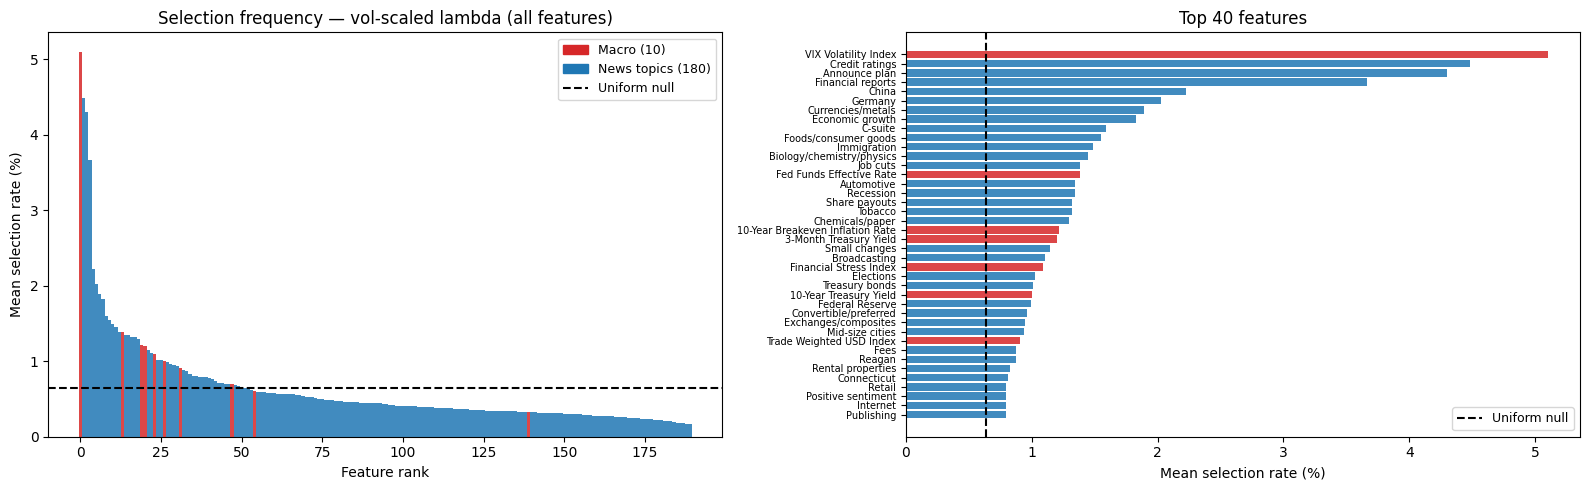

Saved /Users/tommasodifrancesco/Desktop/Lasso_paper/Results/Estimation/Cross_Sectional_volscaled/topic_selection_frequency_volscaled.png


In [8]:
MACRO_SET = {
    '10-Year_Breakeven_Inflation_Rate', '10-Year_Treasury_Yield',
    '3-Month_Treasury_Yield', 'Fed_Funds_Effective_Rate',
    'Financial_Stress_Index', 'High_Yield_Option-Adjusted_Spread',
    'Trade_Weighted_USD_Index', 'USD_to_JPY', 'VIX_Volatility_Index',
    'WTI_Crude_Oil'
}
topics_arr = np.array(topics_ref)
is_macro   = np.array([t in MACRO_SET for t in topics_arr])

mean_sel  = sel_valid.mean(axis=(0, 2))     # mean over stocks and dates
null_rate = mean_sel.sum() / len(topics_arr)
sort_idx  = np.argsort(mean_sel)[::-1]
topics_sorted   = topics_arr[sort_idx]
mean_sel_sorted = mean_sel[sort_idx]
is_macro_sorted = is_macro[sort_idx]

vals = np.sort(mean_sel)
cum  = np.cumsum(vals) / vals.sum()
gini = 1 - 2 * np.trapezoid(cum, np.linspace(0, 1, len(vals)))

macro_rates = mean_sel[is_macro] * 100
topic_rates = mean_sel[~is_macro] * 100

print(f'Null uniform rate          : {null_rate*100:.4f}%')
print(f'Top feature / null         : {mean_sel_sorted[0]/null_rate:.1f}x')
print(f'Gini coefficient           : {gini:.3f}')
print(f'Mean sel rate macro        : {macro_rates.mean():.4f}%')
print(f'Mean sel rate topics       : {topic_rates.mean():.4f}%')
print(f'Macro / topic ratio        : {macro_rates.mean()/topic_rates.mean():.2f}x')
print(f'% features never selected  : {(mean_sel==0).mean()*100:.1f}%')
print()
print('Top 15:')
for i in range(15):
    tag = '[MACRO]' if is_macro_sorted[i] else '[topic]'
    print(f'  {i+1:2d}. {topics_sorted[i].replace("_"," "):<45s} {mean_sel_sorted[i]*100:.3f}%  {tag}')

# Ranked bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['#d62728' if m else '#1f77b4' for m in is_macro_sorted]

ax = axes[0]
ax.bar(range(len(mean_sel_sorted)), mean_sel_sorted*100, color=colors, alpha=0.85, width=1.0)
ax.axhline(null_rate*100, color='k', ls='--', lw=1.5)
ax.set_xlabel('Feature rank'); ax.set_ylabel('Mean selection rate (%)')
ax.set_title('Selection frequency — vol-scaled lambda (all features)')
ax.legend(handles=[
    mpatches.Patch(color='#d62728', label=f'Macro ({is_macro.sum()})'),
    mpatches.Patch(color='#1f77b4', label=f'News topics ({(~is_macro).sum()})'),
    plt.Line2D([0],[0], color='k', ls='--', lw=1.5, label='Uniform null'),
], fontsize=9)

n_top = 40
top_colors = ['#d62728' if m else '#1f77b4' for m in is_macro_sorted[:n_top]]
ax2 = axes[1]
ax2.barh(range(n_top), mean_sel_sorted[:n_top][::-1]*100, color=top_colors[::-1], alpha=0.85)
ax2.set_yticks(range(n_top))
ax2.set_yticklabels([t.replace('_',' ') for t in topics_sorted[:n_top][::-1]], fontsize=7)
ax2.axvline(null_rate*100, color='k', ls='--', lw=1.5, label='Uniform null')
ax2.set_xlabel('Mean selection rate (%)'); ax2.set_title('Top 40 features')
ax2.legend(fontsize=9)

plt.tight_layout()
fig_path = OUT_DIR / 'topic_selection_frequency_volscaled.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {fig_path}')
